# Reintegration Readiness Pipeline Using Real Lighthouse Data

This notebook replaces the synthetic-data prototype with a real-data pipeline built from the uploaded Lighthouse CSV files.

## What this notebook does
- Loads the real Lighthouse relational CSV data
- Builds one modeling row per resident
- Engineers features from education, health, incidents, home visitations, and process recordings
- Creates a real target from `reintegration_status`
- Trains interpretable and tree-based baseline models
- Evaluates performance with ROC-AUC, average precision, classification report, and confusion matrix
- Saves the best pipeline for later use

## Important notes
- This predicts **reintegration readiness / completion status** as a supervised classification task.
- To avoid obvious leakage, the target column itself is **not** used as a feature.
- Because the dataset is relatively small, results should be treated as a **prototype / decision-support model**, not a final production system.


In [28]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import zipfile
import os

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import joblib

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)


In [29]:
# Load relevant tables
from pythondbconnection import importTableFromDb
residents = importTableFromDb("dbo.residents")
education = importTableFromDb("dbo.education_records")
health = importTableFromDb("dbo.health_wellbeing_records")
incidents = importTableFromDb("dbo.incident_reports")
plans = importTableFromDb("dbo.intervention_plans")
visits = importTableFromDb("dbo.home_visitations")
sessions = importTableFromDb("dbo.process_recordings")

print("residents:", residents.shape)
print("education:", education.shape)
print("health:", health.shape)
print("incidents:", incidents.shape)
print("plans:", plans.shape)
print("visits:", visits.shape)
print("sessions:", sessions.shape)


residents: (60, 49)
education: (534, 10)
health: (534, 14)
incidents: (100, 12)
plans: (180, 11)
visits: (1337, 14)
sessions: (2810, 15)


## Create the target

We use `reintegration_status` to define the label:

- `Completed` → 1 (ready / successful reintegration)
- everything else → 0

This is a practical starting target for supervised learning. For a later version, you could refine the target to incorporate timing or other outcome rules.


In [30]:
# Basic cleanup and date parsing
date_cols_residents = [
    "date_of_birth", "date_of_admission", "date_colb_registered", "date_colb_obtained",
    "date_case_study_prepared", "date_enrolled", "date_closed", "created_at"
]
for c in date_cols_residents:
    if c in residents.columns:
        residents[c] = pd.to_datetime(residents[c], errors="coerce")

for df, cols in [
    (education, ["record_date"]),
    (health, ["record_date"]),
    (incidents, ["incident_date", "resolution_date"]),
    (plans, ["target_date", "case_conference_date", "created_at", "updated_at"]),
    (visits, ["visit_date"]),
    (sessions, ["session_date"]),
]:
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

# Real target
residents["ready_for_reintegration"] = (
    residents["reintegration_status"].fillna("").str.strip().str.lower().eq("completed")
).astype(int)

residents[["resident_id", "reintegration_status", "ready_for_reintegration"]].head()


,resident_id,reintegration_status,ready_for_reintegration
0,1,In Progress,0
1,2,Completed,1
2,3,Completed,1
3,4,On Hold,0
4,5,Completed,1


## Engineer resident-level features

The prototype notebook expected a flat table. The real data is relational, so we aggregate each table by `resident_id`.


In [31]:
# Resident / intake-level features
resident_features = residents.copy()

# Derive numeric age / stay features from dates when possible
reference_date = pd.Timestamp.today().normalize()

resident_features["admission_age_years"] = (
    (resident_features["date_of_admission"] - resident_features["date_of_birth"]).dt.days / 365.25
)
resident_features["days_since_admission"] = (
    (reference_date - resident_features["date_of_admission"]).dt.days
)
resident_features["days_until_case_closed_from_admission"] = (
    (resident_features["date_closed"] - resident_features["date_of_admission"]).dt.days
)

# Keep only columns that are plausibly usable as non-leaky baseline features
base_keep = [
    "resident_id",
    "ready_for_reintegration",
    "sex",
    "birth_status",
    "place_of_birth",
    "religion",
    "case_category",
    "sub_cat_orphaned",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "sub_cat_cicl",
    "sub_cat_at_risk",
    "sub_cat_street_child",
    "sub_cat_child_with_hiv",
    "is_pwd",
    "pwd_type",
    "has_special_needs",
    "special_needs_diagnosis",
    "family_is_4ps",
    "family_solo_parent",
    "family_indigenous",
    "family_parent_pwd",
    "family_informal_settler",
    "admission_age_years",
    "referral_source",
    "assigned_social_worker",
    "initial_case_assessment",
    "reintegration_type",
    "initial_risk_level",
    "current_risk_level",
    "days_since_admission",
]

resident_features = resident_features[base_keep].copy()
resident_features.head()


,resident_id,ready_for_reintegration,sex,birth_status,place_of_birth,religion,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,is_pwd,pwd_type,has_special_needs,special_needs_diagnosis,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,admission_age_years,referral_source,assigned_social_worker,initial_case_assessment,reintegration_type,initial_risk_level,current_risk_level,days_since_admission
0,1,0,F,Marital,Davao City,Unspecified,Neglected,False,False,False,False,False,False,False,False,False,False,False,None,True,Speech Impairment,False,False,False,False,False,15.126626,NGO,SW-15,For Reunification,Foster Care,Critical,High,903
1,2,1,F,Marital,Cebu City,Seventh-day Adventist,Surrendered,False,False,False,False,False,False,False,True,True,False,False,None,False,None,False,False,True,False,False,14.899384,Government Agency,SW-14,For Continued Care,Family Reunification,Medium,Medium,1116
2,3,1,F,Marital,Manila,Roman Catholic,Surrendered,False,False,False,False,True,False,False,False,False,False,False,None,False,None,False,False,False,False,False,17.311431,Government Agency,SW-20,For Independent Living,Foster Care,Medium,Medium,683
3,4,0,F,Marital,Davao City,Evangelical,Neglected,False,False,False,False,False,False,True,False,False,False,False,None,False,None,False,False,False,False,False,12.246407,Court Order,SW-15,For Reunification,None,High,Low,557
4,5,1,F,Marital,Pasay City,Buddhism,Surrendered,False,False,False,True,False,True,False,False,False,False,True,Intellectual,False,None,True,False,False,False,False,14.724162,Self-Referral,SW-04,For Independent Living,Family Reunification,Medium,Low,818


In [32]:
# Education aggregates
edu = education.copy()
edu = edu.sort_values(["resident_id", "record_date"])

edu_counts = edu.groupby("resident_id").size().rename("education_record_count")
edu_mean = edu.groupby("resident_id")[["attendance_rate", "progress_percent"]].mean().add_prefix("edu_mean_")
edu_max = edu.groupby("resident_id")[["attendance_rate", "progress_percent"]].max().add_prefix("edu_max_")
edu_last = (
    edu.groupby("resident_id")
       .tail(1)[["resident_id", "education_level", "school_name", "enrollment_status", "completion_status", "attendance_rate", "progress_percent"]]
       .rename(columns={
           "education_level": "edu_last_level",
           "school_name": "edu_last_school_name",
           "enrollment_status": "edu_last_enrollment_status",
           "completion_status": "edu_last_completion_status",
           "attendance_rate": "edu_last_attendance_rate",
           "progress_percent": "edu_last_progress_percent",
       })
       .set_index("resident_id")
)

edu_completed = (
    edu.assign(completed_flag=edu["completion_status"].fillna("").str.lower().eq("completed").astype(int))
       .groupby("resident_id")["completed_flag"].sum()
       .rename("edu_completed_count")
)

edu_features = pd.concat([edu_counts, edu_mean, edu_max, edu_last, edu_completed], axis=1).reset_index()
edu_features.head()


,resident_id,education_record_count,edu_mean_attendance_rate,edu_mean_progress_percent,edu_max_attendance_rate,edu_max_progress_percent,edu_last_level,edu_last_school_name,edu_last_enrollment_status,edu_last_completion_status,edu_last_attendance_rate,edu_last_progress_percent,edu_completed_count
0,1,6,0.716333,45.483333,0.966,54.0,Primary,School 2,Enrolled,InProgress,0.493,52.8,0
1,2,10,0.834300,85.230000,1.000,100.0,Secondary,School 11,Enrolled,InProgress,0.851,100.0,0
2,3,11,0.738091,71.581818,0.894,100.0,Secondary,School 17,Enrolled,InProgress,0.868,100.0,1
3,4,11,0.757636,95.045455,0.920,100.0,Secondary,School 11,Enrolled,Completed,0.880,100.0,1
4,5,9,0.668111,61.388889,0.856,80.8,Primary,School 9,Enrolled,InProgress,0.856,80.8,0


In [33]:
# Health aggregates
hlth = health.copy().sort_values(["resident_id", "record_date"])

health_num_cols = [
    "general_health_score", "nutrition_score", "sleep_quality_score",
    "energy_level_score", "height_cm", "weight_kg", "bmi"
]

health_mean = hlth.groupby("resident_id")[health_num_cols].mean().add_prefix("health_mean_")
health_last = (
    hlth.groupby("resident_id").tail(1)[
        ["resident_id"] + health_num_cols + ["medical_checkup_done", "dental_checkup_done", "psychological_checkup_done"]
    ]
    .rename(columns={
        "general_health_score": "health_last_general_health_score",
        "nutrition_score": "health_last_nutrition_score",
        "sleep_quality_score": "health_last_sleep_quality_score",
        "energy_level_score": "health_last_energy_level_score",
        "height_cm": "health_last_height_cm",
        "weight_kg": "health_last_weight_kg",
        "bmi": "health_last_bmi",
        "medical_checkup_done": "health_last_medical_checkup_done",
        "dental_checkup_done": "health_last_dental_checkup_done",
        "psychological_checkup_done": "health_last_psychological_checkup_done",
    })
    .set_index("resident_id")
)

health_features = pd.concat([health_mean, health_last], axis=1).reset_index()
health_features.head()


,resident_id,health_mean_general_health_score,health_mean_nutrition_score,health_mean_sleep_quality_score,health_mean_energy_level_score,health_mean_height_cm,health_mean_weight_kg,health_mean_bmi,health_last_general_health_score,health_last_nutrition_score,health_last_sleep_quality_score,health_last_energy_level_score,health_last_height_cm,health_last_weight_kg,health_last_bmi,health_last_medical_checkup_done,health_last_dental_checkup_done,health_last_psychological_checkup_done
0,1,3.103333,3.210000,3.203333,2.908333,151.850000,35.966667,15.583333,3.22,3.39,3.20,2.91,152.4,36.7,15.8,False,False,False
1,2,3.449000,3.431000,3.376000,3.001000,149.480000,40.760000,18.220000,3.62,3.67,3.40,3.08,150.8,41.9,18.4,True,False,False
2,3,3.181818,3.003636,3.079091,3.215455,151.418182,39.136364,17.063636,3.57,3.39,3.07,3.58,152.9,40.3,17.2,False,False,True
3,4,3.157273,2.983636,2.881818,2.996364,153.609091,39.981818,16.936364,3.11,3.10,2.82,3.11,154.7,41.1,17.2,True,False,False
4,5,3.087778,3.100000,2.981111,3.012222,152.122222,39.544444,17.088889,3.06,3.28,3.01,3.18,153.3,40.5,17.2,True,False,False


In [34]:
# Incident aggregates
inc = incidents.copy().sort_values(["resident_id", "incident_date"])

sev_map = {"low": 1, "medium": 2, "high": 3}
inc["severity_score"] = inc["severity"].astype(str).str.lower().map(sev_map)

incident_features = (
    inc.groupby("resident_id")
       .agg(
           incident_count=("incident_id", "count"),
           high_severity_count=("severity", lambda s: s.astype(str).str.lower().eq("high").sum()),
           unresolved_incident_count=("resolved", lambda s: (~s.fillna(False).astype(bool)).sum()),
           follow_up_required_count=("follow_up_required", lambda s: s.fillna(False).astype(bool).sum()),
           mean_incident_severity_score=("severity_score", "mean"),
       )
       .reset_index()
)

incident_last = (
    inc.groupby("resident_id").tail(1)[["resident_id", "incident_type", "severity", "resolved", "follow_up_required"]]
      .rename(columns={
          "incident_type": "last_incident_type",
          "severity": "last_incident_severity",
          "resolved": "last_incident_resolved",
          "follow_up_required": "last_incident_follow_up_required",
      })
)

incident_features = incident_features.merge(incident_last, on="resident_id", how="left")
incident_features.head()


,resident_id,incident_count,high_severity_count,unresolved_incident_count,follow_up_required_count,mean_incident_severity_score,last_incident_type,last_incident_severity,last_incident_resolved,last_incident_follow_up_required
0,1,4,1,1,1,1.750000,Security,High,False,True
1,3,2,1,2,2,2.000000,SelfHarm,High,False,True
2,4,3,1,0,1,1.666667,ConflictWithPeer,High,True,True
3,5,2,1,1,2,2.500000,Security,Medium,False,True
4,6,2,0,0,0,1.500000,ConflictWithPeer,Low,True,False


In [35]:
# Intervention plan aggregates
pln = plans.copy().sort_values(["resident_id", "updated_at", "created_at"])

plan_features = (
    pln.groupby("resident_id")
       .agg(
           plan_count=("plan_id", "count"),
           distinct_plan_categories=("plan_category", "nunique"),
           mean_plan_target_value=("target_value", "mean"),
           in_progress_plan_count=("status", lambda s: s.astype(str).str.lower().eq("in progress").sum()),
           completed_plan_count=("status", lambda s: s.astype(str).str.lower().eq("completed").sum()),
           on_hold_plan_count=("status", lambda s: s.astype(str).str.lower().eq("on hold").sum()),
       )
       .reset_index()
)

plan_last = (
    pln.groupby("resident_id").tail(1)[["resident_id", "plan_category", "status", "services_provided"]]
       .rename(columns={
           "plan_category": "last_plan_category",
           "status": "last_plan_status",
           "services_provided": "last_plan_services_provided",
       })
)

plan_features = plan_features.merge(plan_last, on="resident_id", how="left")
plan_features.head()


,resident_id,plan_count,distinct_plan_categories,mean_plan_target_value,in_progress_plan_count,completed_plan_count,on_hold_plan_count,last_plan_category,last_plan_status,last_plan_services_provided
0,1,3,3,3.083333,1,0,2,Physical Health,On Hold,"Teaching, Healing, Caring"
1,2,3,3,3.083333,0,0,1,Physical Health,Achieved,"Legal Services, Caring, Teaching"
2,3,3,3,3.083333,0,0,1,Physical Health,Open,"Legal Services, Healing, Teaching"
3,4,3,3,3.083333,2,0,0,Physical Health,In Progress,"Teaching, Legal Services"
4,5,3,3,3.083333,2,0,0,Physical Health,Achieved,"Teaching, Healing, Caring"


In [36]:
# Home visitation aggregates
v = visits.copy().sort_values(["resident_id", "visit_date"])

visit_features = (
    v.groupby("resident_id")
     .agg(
         visit_count=("visitation_id", "count"),
         safety_concerns_count=("safety_concerns_noted", lambda s: s.fillna(False).astype(bool).sum()),
         follow_up_needed_count=("follow_up_needed", lambda s: s.fillna(False).astype(bool).sum()),
         favorable_visit_count=("visit_outcome", lambda s: s.astype(str).str.lower().eq("favorable").sum()),
     )
     .reset_index()
)

visit_last = (
    v.groupby("resident_id").tail(1)[["resident_id", "visit_type", "location_visited", "family_cooperation_level", "visit_outcome"]]
     .rename(columns={
         "visit_type": "last_visit_type",
         "location_visited": "last_location_visited",
         "family_cooperation_level": "last_family_cooperation_level",
         "visit_outcome": "last_visit_outcome",
     })
)

visit_features = visit_features.merge(visit_last, on="resident_id", how="left")
visit_features.head()


,resident_id,visit_count,safety_concerns_count,follow_up_needed_count,favorable_visit_count,last_visit_type,last_location_visited,last_family_cooperation_level,last_visit_outcome
0,1,54,9,27,18,Reintegration Assessment,Church,Highly Cooperative,Needs Improvement
1,2,35,11,17,15,Reintegration Assessment,School,Cooperative,Favorable
2,3,26,11,12,9,Routine Follow-Up,Family Home,Cooperative,Needs Improvement
3,4,9,3,3,5,Post-Placement Monitoring,Church,Highly Cooperative,Needs Improvement
4,5,11,2,3,6,Routine Follow-Up,Proposed Foster Home,Highly Cooperative,Favorable


In [37]:
# Process recording aggregates
sess = sessions.copy().sort_values(["resident_id", "session_date"])

session_features = (
    sess.groupby("resident_id")
        .agg(
            session_count=("recording_id", "count"),
            mean_session_duration_minutes=("session_duration_minutes", "mean"),
            progress_noted_count=("progress_noted", lambda s: s.fillna(False).astype(bool).sum()),
            concerns_flagged_count=("concerns_flagged", lambda s: s.fillna(False).astype(bool).sum()),
            referral_made_count=("referral_made", lambda s: s.fillna(False).astype(bool).sum()),
        )
        .reset_index()
)

session_last = (
    sess.groupby("resident_id").tail(1)[["resident_id", "session_type", "emotional_state_observed", "emotional_state_end", "interventions_applied"]]
        .rename(columns={
            "session_type": "last_session_type",
            "emotional_state_observed": "last_emotional_state_observed",
            "emotional_state_end": "last_emotional_state_end",
            "interventions_applied": "last_interventions_applied",
        })
)

session_features = session_features.merge(session_last, on="resident_id", how="left")
session_features.head()


,resident_id,session_count,mean_session_duration_minutes,progress_noted_count,concerns_flagged_count,referral_made_count,last_session_type,last_emotional_state_observed,last_emotional_state_end,last_interventions_applied
0,1,106,69.433962,98,25,17,Individual,Withdrawn,Calm,"Teaching, Caring, Legal Services"
1,2,51,68.176471,47,13,7,Individual,Sad,Calm,Healing
2,3,53,69.452830,50,10,10,Individual,Calm,Hopeful,Legal Services
3,4,57,69.596491,55,12,7,Individual,Withdrawn,Hopeful,"Healing, Legal Services"
4,5,18,65.611111,18,3,1,Individual,Withdrawn,Calm,"Healing, Caring, Teaching"


In [38]:
# Merge all engineered features into one modeling table
df = resident_features.copy()

for feat_df in [edu_features, health_features, incident_features, plan_features, visit_features, session_features]:
    df = df.merge(feat_df, on="resident_id", how="left")

print(df.shape)
df.head()


(60, 98)


,resident_id,ready_for_reintegration,sex,birth_status,place_of_birth,religion,case_category,sub_cat_orphaned,sub_cat_trafficked,sub_cat_child_labor,sub_cat_physical_abuse,sub_cat_sexual_abuse,sub_cat_osaec,sub_cat_cicl,sub_cat_at_risk,sub_cat_street_child,sub_cat_child_with_hiv,is_pwd,pwd_type,has_special_needs,special_needs_diagnosis,family_is_4ps,family_solo_parent,family_indigenous,family_parent_pwd,family_informal_settler,admission_age_years,referral_source,assigned_social_worker,initial_case_assessment,reintegration_type,initial_risk_level,current_risk_level,days_since_admission,education_record_count,edu_mean_attendance_rate,edu_mean_progress_percent,edu_max_attendance_rate,edu_max_progress_percent,edu_last_level,edu_last_school_name,edu_last_enrollment_status,edu_last_completion_status,edu_last_attendance_rate,edu_last_progress_percent,edu_completed_count,health_mean_general_health_score,health_mean_nutrition_score,health_mean_sleep_quality_score,health_mean_energy_level_score,health_mean_height_cm,health_mean_weight_kg,health_mean_bmi,health_last_general_health_score,health_last_nutrition_score,health_last_sleep_quality_score,health_last_energy_level_score,health_last_height_cm,health_last_weight_kg,health_last_bmi,health_last_medical_checkup_done,health_last_dental_checkup_done,health_last_psychological_checkup_done,incident_count,high_severity_count,unresolved_incident_count,follow_up_required_count,mean_incident_severity_score,last_incident_type,last_incident_severity,last_incident_resolved,last_incident_follow_up_required,plan_count,distinct_plan_categories,mean_plan_target_value,in_progress_plan_count,completed_plan_count,on_hold_plan_count,last_plan_category,last_plan_status,last_plan_services_provided,visit_count,safety_concerns_count,follow_up_needed_count,favorable_visit_count,last_visit_type,last_location_visited,last_family_cooperation_level,last_visit_outcome,session_count,mean_session_duration_minutes,progress_noted_count,concerns_flagged_count,referral_made_count,last_session_type,last_emotional_state_observed,last_emotional_state_end,last_interventions_applied
0,1,0,F,Marital,Davao City,Unspecified,Neglected,False,False,False,False,False,False,False,False,False,False,False,None,True,Speech Impairment,False,False,False,False,False,15.126626,NGO,SW-15,For Reunification,Foster Care,Critical,High,903,6,0.716333,45.483333,0.966,54.0,Primary,School 2,Enrolled,InProgress,0.493,52.8,0,3.103333,3.210000,3.203333,2.908333,151.850000,35.966667,15.583333,3.22,3.39,3.20,2.91,152.4,36.7,15.8,False,False,False,4.0,1.0,1.0,1.0,1.750000,Security,High,False,True,3,3,3.083333,1,0,2,Physical Health,On Hold,"Teaching, Healing, Caring",54.0,9.0,27.0,18.0,Reintegration Assessment,Church,Highly Cooperative,Needs Improvement,106,69.433962,98,25,17,Individual,Withdrawn,Calm,"Teaching, Caring, Legal Services"
1,2,1,F,Marital,Cebu City,Seventh-day Adventist,Surrendered,False,False,False,False,False,False,False,True,True,False,False,None,False,None,False,False,True,False,False,14.899384,Government Agency,SW-14,For Continued Care,Family Reunification,Medium,Medium,1116,10,0.834300,85.230000,1.000,100.0,Secondary,School 11,Enrolled,InProgress,0.851,100.0,0,3.449000,3.431000,3.376000,3.001000,149.480000,40.760000,18.220000,3.62,3.67,3.40,3.08,150.8,41.9,18.4,True,False,False,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,3,3.083333,0,0,1,Physical Health,Achieved,"Legal Services, Caring, Teaching",35.0,11.0,17.0,15.0,Reintegration Assessment,School,Cooperative,Favorable,51,68.176471,47,13,7,Individual,Sad,Calm,Healing
2,3,1,F,Marital,Manila,Roman Catholic,Surrendered,False,False,False,False,True,False,False,False,False,False,False,None,False,None,False,False,False,False,False,17.311431,Government Agency,SW-20,For Independent Living,Foster Care,Medium,Medium,683,11,0.738091,71.581818,0.894,100.0,Secondary,School 17,Enrolled,InProgress,0.868,100.0,1,3.181818,3.003636,3.079091,3.215455,151.418182,39.136364,17.063636,3.57,3.39,3.07,3.58,152.9,40.3,1

## Quick target check

In [39]:
df["ready_for_reintegration"].value_counts(dropna=False)


ready_for_reintegration
0    41
1    19
Name: count, dtype: int64

## Prepare features and preprocessing

We explicitly remove:
- the target
- identifier columns
- obvious target leakage columns like the original `reintegration_status`


In [40]:
X = df.drop(columns=["resident_id", "ready_for_reintegration"], errors="ignore").copy()
y = df["ready_for_reintegration"].copy()

# Convert booleans to object-safe representation? Not needed, sklearn handles bool.
# Identify column types
categorical_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object", "category"]).columns.tolist()

print("Categorical columns:", len(categorical_cols))
print("Numeric columns:", len(numeric_cols))
print("Rows:", len(X))


Categorical columns: 32
Numeric columns: 64
Rows: 60


In [41]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols),
    ]
)


## Train/test split

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape, y_train.mean())
print("Test shape:", X_test.shape, y_test.mean())


Train shape: (45, 96) 0.3111111111111111
Test shape: (15, 96) 0.3333333333333333


## Compare two baseline models

Because the dataset is small, we compare:
1. **Balanced Logistic Regression** — simpler, more interpretable
2. **Balanced Random Forest** — nonlinear baseline


In [43]:
models = {
    "logistic_regression": LogisticRegression(max_iter=2000, class_weight="balanced"),
    "random_forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        min_samples_leaf=2,
        random_state=42,
        class_weight="balanced_subsample"
    ),
}

results = {}

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    roc = roc_auc_score(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)

    results[name] = {
        "pipeline": pipe,
        "roc_auc": roc,
        "avg_precision": ap,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

pd.DataFrame({
    name: {"ROC_AUC": vals["roc_auc"], "Average_Precision": vals["avg_precision"]}
    for name, vals in results.items()
}).T.sort_values("ROC_AUC", ascending=False)


,ROC_AUC,Average_Precision
logistic_regression,0.56,0.437143
random_forest,0.50,0.374156


In [44]:
# Cross-validation for a more stable view on such a small dataset
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_rows = []
for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ])
    scores = cross_validate(
        pipe,
        X, y,
        cv=cv,
        scoring={"roc_auc": "roc_auc", "avg_precision": "average_precision"},
        n_jobs=None,
        return_train_score=False
    )
    cv_rows.append({
        "model": name,
        "cv_mean_roc_auc": np.mean(scores["test_roc_auc"]),
        "cv_std_roc_auc": np.std(scores["test_roc_auc"]),
        "cv_mean_avg_precision": np.mean(scores["test_avg_precision"]),
        "cv_std_avg_precision": np.std(scores["test_avg_precision"]),
    })

cv_df = pd.DataFrame(cv_rows).sort_values("cv_mean_roc_auc", ascending=False)
cv_df


,model,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_avg_precision,cv_std_avg_precision
0,logistic_regression,0.642361,0.184558,0.512579,0.138043
1,random_forest,0.504167,0.126827,0.429558,0.129870


## Pick the best model and evaluate on the holdout set

In [45]:
best_model_name = cv_df.iloc[0]["model"]
best_pipe = results[best_model_name]["pipeline"]
y_prob = results[best_model_name]["y_prob"]
y_pred = results[best_model_name]["y_pred"]

print("Best model:", best_model_name)
print("Holdout ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Holdout Average Precision:", average_precision_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred, digits=3))


Best model: logistic_regression
Holdout ROC-AUC: 0.56
Holdout Average Precision: 0.43714285714285717

              precision    recall  f1-score   support

           0      0.667     0.600     0.632        10
           1      0.333     0.400     0.364         5

    accuracy                          0.533        15
   macro avg      0.500     0.500     0.498        15
weighted avg      0.556     0.533     0.542        15



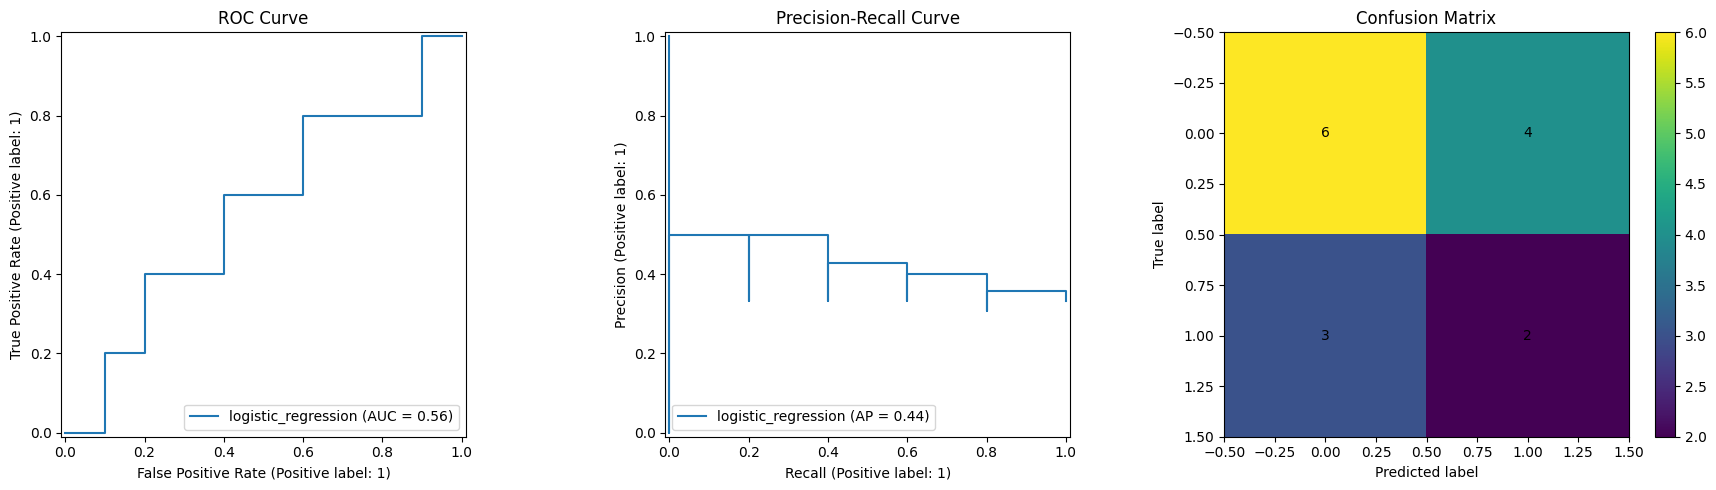

In [46]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

RocCurveDisplay.from_predictions(y_test, y_prob, ax=axes[0], name=best_model_name)
axes[0].set_title("ROC Curve")

PrecisionRecallDisplay.from_predictions(y_test, y_prob, ax=axes[1], name=best_model_name)
axes[1].set_title("Precision-Recall Curve")

cm = confusion_matrix(y_test, y_pred)
im = axes[2].imshow(cm)
axes[2].set_title("Confusion Matrix")
axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[2].text(j, i, cm[i, j], ha="center", va="center")

fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


## Optional: threshold tuning

If recall on the positive class is poor, try a lower threshold than 0.50.


In [47]:
thresholds = [0.30, 0.40, 0.50, 0.60]
threshold_reports = []

for t in thresholds:
    pred_t = (y_prob >= t).astype(int)
    cm_t = confusion_matrix(y_test, pred_t)
    report = classification_report(y_test, pred_t, output_dict=True, zero_division=0)
    threshold_reports.append({
        "threshold": t,
        "precision_class_1": report.get("1", {}).get("precision", np.nan),
        "recall_class_1": report.get("1", {}).get("recall", np.nan),
        "f1_class_1": report.get("1", {}).get("f1-score", np.nan),
        "accuracy": report.get("accuracy", np.nan),
        "tn": cm_t[0,0],
        "fp": cm_t[0,1],
        "fn": cm_t[1,0],
        "tp": cm_t[1,1],
    })

pd.DataFrame(threshold_reports)


,threshold,precision_class_1,recall_class_1,f1_class_1,accuracy,tn,fp,fn,tp
0,0.3,0.375000,0.6,0.461538,0.533333,5,5,2,3
1,0.4,0.333333,0.4,0.363636,0.533333,6,4,3,2
2,0.5,0.333333,0.4,0.363636,0.533333,6,4,3,2
3,0.6,0.400000,0.4,0.400000,0.600000,7,3,3,2


## Save the best pipeline

In [48]:
import pickle, os
import pandas as pd

os.makedirs("models", exist_ok=True)

# Keep feature list consistent
selected_features = list(X_train.columns)

# Final trained pipeline
final_model = best_pipe

# Save artifact in same format as churn
with open("models/reintegration_model.pkl", "wb") as f:
    pickle.dump({
        "model": final_model,
        "features": selected_features,
        "threshold": best_threshold if 'best_threshold' in globals() else 0.5,
        "target_name": "ready_for_reintegration"
    }, f)

print("Model saved to models/reintegration_model.pkl")


# 🔥 Example scoring (same pattern as churn)

new_residents = X_test[selected_features].iloc[:5].copy()
probs = final_model.predict_proba(new_residents)[:, 1]

new_residents["readiness_probability"] = probs
new_residents["prediction"] = (probs >= (best_threshold if 'best_threshold' in globals() else 0.5)).astype(int)

new_residents["readiness_tier"] = pd.cut(
    new_residents["readiness_probability"],
    bins=[0, 0.4, 0.65, 1.0],
    labels=["Low", "Medium", "High"]
)

print(new_residents[["readiness_probability", "prediction", "readiness_tier"]])


Model saved to models/reintegration_model.pkl
    readiness_probability  prediction readiness_tier
15               0.999772           1           High
10               0.995998           1           High
32               0.317615           0            Low
47               0.010725           0            Low
23               0.000148           0            Low


## Final interpretation guidance

Use this notebook as a **real-data replacement** for the synthetic prototype.

When writing up results, keep these points honest:
- This is a **valid real-data pipeline**
- Performance depends on the relatively small sample size
- Cross-validation metrics are more reliable than a single split
- This should be described as **decision support / prototype modeling**, not a fully validated production predictor
